In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path.home() / "projekty" / "dzietnosc-polska"
df = pd.read_csv(ROOT / "data" / "raw" / "bdl_polska.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rok                       31 non-null     int64  
 1   tfr                       24 non-null     float64
 2   urodzenia_zywe            31 non-null     int64  
 3   zgony                     31 non-null     int64  
 4   ludnosc_przedprodukcyjna  31 non-null     int64  
 5   ludnosc_produkcyjna       31 non-null     int64  
 6   ludnosc_poprodukcyjna     31 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 1.8 KB


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

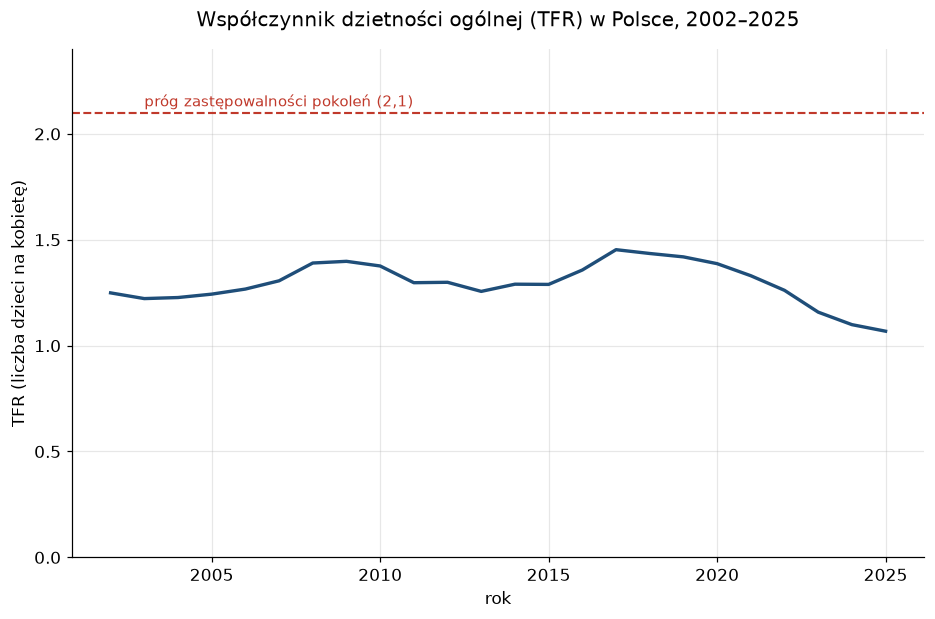

In [3]:
fig, ax = plt.subplots()

ax.plot(df["rok"], df["tfr"], color="#1f4e79", linewidth=2.2)

ax.axhline(2.1, color="#c0392b", linestyle="--", linewidth=1.4)

ax.text(2003, 2.13, "próg zastępowalności pokoleń (2,1)",
        color="#c0392b", fontsize=10)

ax.set_title("Współczynnik dzietności ogólnej (TFR) w Polsce, 2002–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("TFR (liczba dzieci na kobietę)")
ax.set_ylim(0, 2.4)

fig.savefig(ROOT / "figures" / "01_tfr_polska.png", dpi=200, bbox_inches="tight")

plt.show()

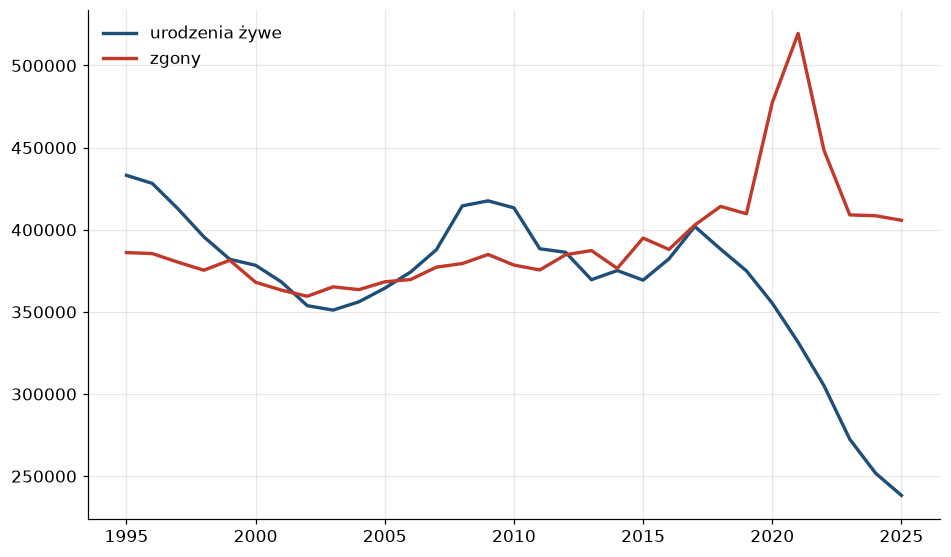

In [4]:
fig, ax = plt.subplots()

ax.plot(df["rok"], df["urodzenia_zywe"], color="#1f4e79",
        linewidth=2.2, label="urodzenia żywe")
ax.plot(df["rok"], df["zgony"], color="#c0392b",
        linewidth=2.2, label="zgony")

ax.legend(frameon=False)

plt.show()

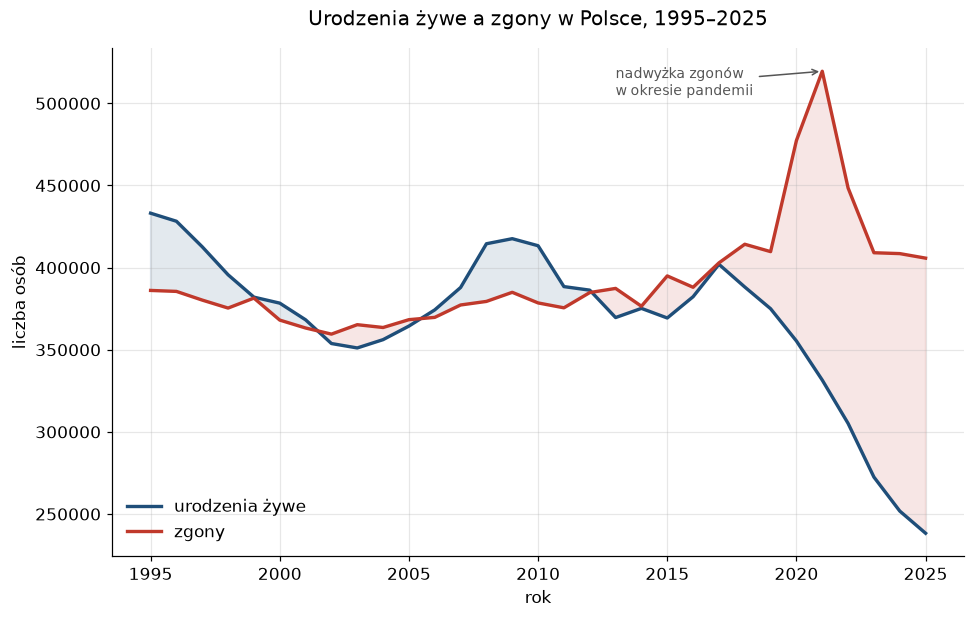

In [6]:
fig, ax = plt.subplots()

ax.fill_between(df["rok"], df["urodzenia_zywe"], df["zgony"],
                where=df["urodzenia_zywe"] >= df["zgony"],
                color="#1f4e79", alpha=0.12, interpolate=True)
ax.fill_between(df["rok"], df["urodzenia_zywe"], df["zgony"],
                where=df["urodzenia_zywe"] < df["zgony"],
                color="#c0392b", alpha=0.12, interpolate=True)

ax.plot(df["rok"], df["urodzenia_zywe"], color="#1f4e79",
        linewidth=2.2, label="urodzenia żywe")
ax.plot(df["rok"], df["zgony"], color="#c0392b",
        linewidth=2.2, label="zgony")

ax.annotate("nadwyżka zgonów\nw okresie pandemii",
            xy=(2021, 519517), xytext=(2013, 505000),
            fontsize=9, color="#555555",
            arrowprops=dict(arrowstyle="->", color="#555555", lw=1))

ax.set_title("Urodzenia żywe a zgony w Polsce, 1995–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("liczba osób")
ax.legend(frameon=False, loc="lower left")

fig.savefig(ROOT / "figures" / "02_urodzenia_zgony.png",
            dpi=200, bbox_inches="tight")

plt.show()

In [7]:
df["ludnosc_ogolem"] = (df["ludnosc_przedprodukcyjna"]
                        + df["ludnosc_produkcyjna"]
                        + df["ludnosc_poprodukcyjna"])

for grupa in ["przedprodukcyjna", "produkcyjna", "poprodukcyjna"]:
    df[f"udzial_{grupa}"] = (df[f"ludnosc_{grupa}"]
                             / df["ludnosc_ogolem"] * 100)

df[["rok", "udzial_przedprodukcyjna",
    "udzial_produkcyjna", "udzial_poprodukcyjna"]].head()

,rok,udzial_przedprodukcyjna,udzial_produkcyjna,udzial_poprodukcyjna
0,1995,27.570497,58.657782,13.771722
1,1996,26.960908,59.058937,13.980156
2,1997,26.294732,59.529192,14.176076
3,1998,25.573849,60.067627,14.358524
4,1999,25.167856,60.217196,14.614948


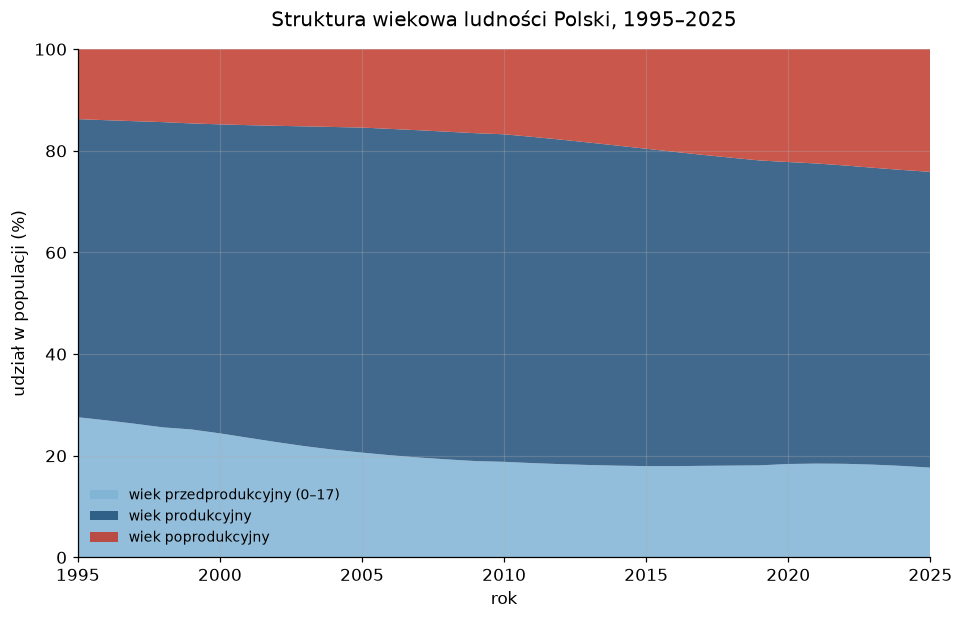

In [8]:
fig, ax = plt.subplots()

ax.stackplot(df["rok"],
             df["udzial_przedprodukcyjna"],
             df["udzial_produkcyjna"],
             df["udzial_poprodukcyjna"],
             labels=["wiek przedprodukcyjny (0–17)",
                     "wiek produkcyjny",
                     "wiek poprodukcyjny"],
             colors=["#7fb3d5", "#1f4e79", "#c0392b"],
             alpha=0.85)

ax.set_title("Struktura wiekowa ludności Polski, 1995–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("udział w populacji (%)")
ax.set_ylim(0, 100)
ax.set_xlim(1995, 2025)
ax.legend(frameon=False, loc="lower left", fontsize=9)

fig.savefig(ROOT / "figures" / "03_struktura_wiekowa.png",
            dpi=200, bbox_inches="tight")

plt.show()

In [9]:
df["obciazenie_starosc"] = (df["ludnosc_poprodukcyjna"]
                            / df["ludnosc_produkcyjna"] * 100)

df["obciazenie_calkowite"] = ((df["ludnosc_przedprodukcyjna"]
                               + df["ludnosc_poprodukcyjna"])
                              / df["ludnosc_produkcyjna"] * 100)

df[["rok", "obciazenie_starosc", "obciazenie_calkowite"]].iloc[[0, 15, 30]]

,rok,obciazenie_starosc,obciazenie_calkowite
0,1995,23.478081,70.480364
15,2010,25.998251,55.168396
30,2025,41.486115,71.822609


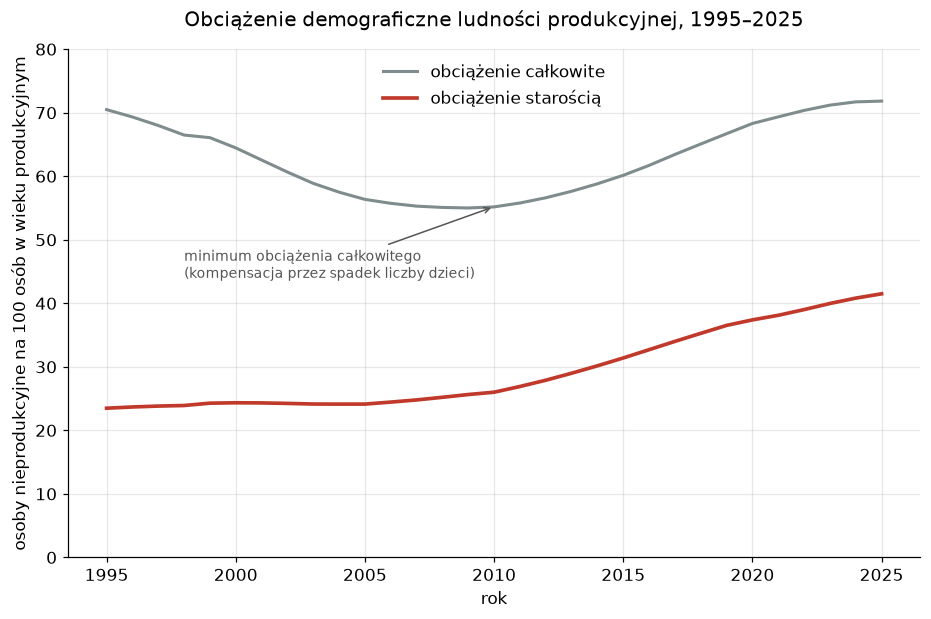

In [10]:
fig, ax = plt.subplots()

ax.plot(df["rok"], df["obciazenie_calkowite"], color="#7f8c8d",
        linewidth=2.0, linestyle="-", label="obciążenie całkowite")
ax.plot(df["rok"], df["obciazenie_starosc"], color="#c0392b",
        linewidth=2.4, label="obciążenie starością")

ax.annotate("minimum obciążenia całkowitego\n(kompensacja przez spadek liczby dzieci)",
            xy=(2010, 55.2), xytext=(1998, 44),
            fontsize=9, color="#555555",
            arrowprops=dict(arrowstyle="->", color="#555555", lw=1))

ax.set_title("Obciążenie demograficzne ludności produkcyjnej, 1995–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("osoby nieprodukcyjne na 100 osób w wieku produkcyjnym")
ax.set_ylim(0, 80)
ax.legend(frameon=False, loc="upper center")

fig.savefig(ROOT / "figures" / "04_obciazenie_demograficzne.png",
            dpi=200, bbox_inches="tight")

plt.show()

In [11]:
kob = pd.read_csv(ROOT / "data" / "raw" / "kohorty_kobiet.csv", index_col="rok")
print(kob.columns.tolist())
print(kob.shape)

['15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49']
(31, 7)


In [12]:
KOHORTY = ["15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49"]
kob["razem"] = kob[KOHORTY].sum(axis=1)

kob[["15-19", "25-29", "45-49", "razem"]].iloc[[0, 15, 30]]

,15-19,25-29,45-49,razem
rok,,,,
1995,1584255,1201447,1380967,10052820
2010,1185934,1610901,1235301,9514328
2025,1002759,951279,1512092,8455859


In [23]:
print((KATALOG_FIG / "05_struktura_kohort.png").exists())
print((KATALOG_FIG / "05_struktura_kohort.png").stat().st_size)

True
94215


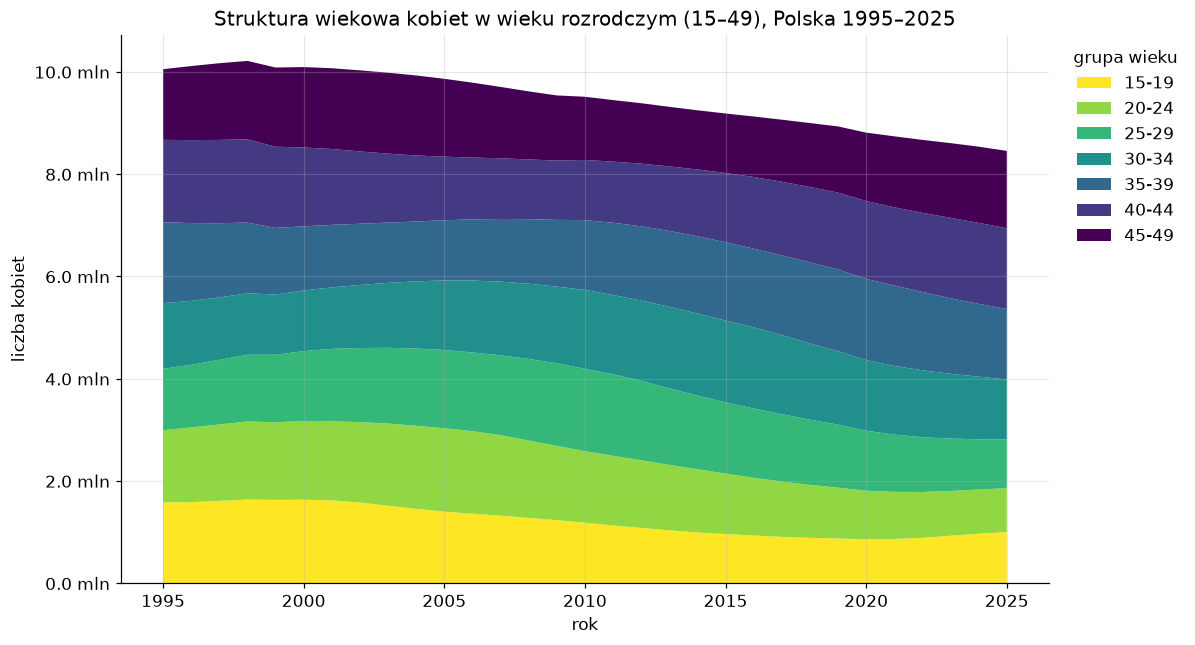

In [24]:
from matplotlib.ticker import FuncFormatter

kolory = plt.cm.viridis_r([i / (len(KOHORTY) - 1) for i in range(len(KOHORTY))])

fig, ax = plt.subplots(figsize=(11, 6))

ax.stackplot(
    kob.index,
    *[kob[k] for k in KOHORTY],
    labels=KOHORTY,
    colors=kolory,
)

ax.set_xlabel("rok")
ax.set_ylabel("liczba kobiet")
ax.set_title("Struktura wiekowa kobiet w wieku rozrodczym (15–49), Polska 1995–2025")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1e6:.1f} mln")
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    ncol=1,
    frameon=False,
    title="grupa wieku",
)

fig.tight_layout()
KATALOG_FIG = ROOT / "figures"
KATALOG_FIG.mkdir(exist_ok=True)

fig.savefig(
    KATALOG_FIG / "05_struktura_kohort.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()